# Intro

## Global parameters

In [2]:
MAX_TIME_HOURS=1
ALPHA=0.01
_PVAL_FLOOR=10**-6

## Modules

### Standard

In [3]:
import os, pickle, platform, sys
import numpy as np
import torch

In [4]:
from collections import defaultdict

In [5]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [7]:
from scipy.stats import spearmanr

In [8]:
from tqdm.notebook import tqdm, trange

In [9]:
import datetime as dt

In [10]:
from bowtie import edges2bowtie

### Home made

In [11]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Air!


In [12]:
from auxiliary_functions import el2ks

In [13]:
from sam_bowtie import block_and_fluxes as bnf

In [16]:
from bowtie_plot_functions import plot_bowtie_blocks, plot_bowtie_fluxes, _add_colorbar
from bowtie_plot_functions import _fdr as fdr

## Load data

In [17]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
GUARINO_FOLDER=HOME+'guarino_files/'
BIPARTITE_FOLDER=HOME+'BiDCM/'
PLOT_FOLDER=HOME+'plots/'

# Looking into the abyss

In [20]:
guarino_files=[file for file in os.listdir(GUARINO_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

In [21]:
bipartite_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
bipartite_files.sort()
bipartite_files

['crisi_dico_0_bowtie_flows.csv',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_flows.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_flows.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_flows.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_flows.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_0_bowtie_flows.csv',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_flows.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_flows.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_flows.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_flows.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_flows.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_flows.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'quirinale_dico_0_bowtie_flows.csv',
 'quirinale_dico_0_bowtie_sizes.cs

### Name of the various dicos

In [22]:
guarino_files[0]

'all_dico_labels.txt'

In [23]:
with open(GUARINO_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()


In [24]:
def parse_dico_names(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip().split() for line in f]
        # such a command creates a list
        # in which each element is a list of tokens of a line in the file
        # remarkably, there is an empty element
        # before each dataset name
        

    result = {}
    current_key = None

    for tokens in lines:
        if not tokens:
            current_key = None
        elif current_key is None:
            # prima riga non vuota del gruppo: nome del dataset
            current_key = tokens[0]
            result[current_key] = {}
        else:
            # riga tipo ['5:', 'journalists', '&', 'Media']
            idx = int(tokens[0].rstrip(':'))
            label = ' '.join(tokens[1:])
            result[current_key][idx] = label

    return result

In [25]:
cacca=parse_dico_names(GUARINO_FOLDER+guarino_files[0])

In [26]:
cacca

{'quirinale': {5: 'journalists & Media',
  2: 'M5S',
  0: 'journalists & IV & Azione & +Europa & Media',
  4: 'Lega & FDI',
  1: 'PD',
  3: 'Media & journalists',
  6: 'FI'},
 'crisi': {1: 'Lega & FDI & FI',
  2: 'M5S & journalists',
  0: 'journalists & IV & Media & Azione & +Europa',
  4: 'Media & journalists',
  3: 'PD'},
 'ita_elections': {1: 'PD & Media & +Europa & journalists',
  2: 'M5S & Media',
  3: 'journalists & IV & Azione',
  0: 'Lega & FDI & FI',
  4: 'journalists & Media (1)',
  5: 'Media',
  6: 'journalists & Media (2)'}}

The pickle is what I need.

# Benchmarking: 

In [27]:
test_files=os.listdir(TEST_FOLDER)
test_files.sort()

## Ita_election
i.e. our main benchmark.

In [28]:
elected_files=[file for file in test_files if file.startswith('ita')]
elected_files

['ita_elections_dico0_qdecm.pkl',
 'ita_elections_dico1_qdecm.pkl',
 'ita_elections_dico2_decm.pkl',
 'ita_elections_dico2_decm_final.pkl',
 'ita_elections_dico2_qdecm.pkl',
 'ita_elections_dico3_decm.pkl',
 'ita_elections_dico3_decm_final.pkl',
 'ita_elections_dico3_decm_final_0.pkl',
 'ita_elections_dico3_qdecm.pkl',
 'ita_elections_dico4_qdecm.pkl',
 'ita_elections_dico5_qdecm.pkl',
 'ita_elections_dico6_qdecm.pkl']

In [29]:
for file in elected_files:
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    file_name_friendly=file[14:25].strip('.')
    if cacca.sol.mre<10**-5:
        print(f"{file_name_friendly}: Ok, MRE={cacca.sol.mre:.1e}")
    else:
        print(f"{file_name_friendly}: Bad! MRE={cacca.sol.mre:.1e} ")

    

dico0_qdecm: Ok, MRE=5.3e-06
dico1_qdecm: Ok, MRE=9.8e-06
dico2_decm: Bad! MRE=8.2e-04 
dico2_decm_: Bad! MRE=8.4e-04 
dico2_qdecm: Ok, MRE=1.1e-06
dico3_decm: Bad! MRE=2.7e-03 
dico3_decm_: Bad! MRE=2.7e-03 
dico3_decm_: Bad! MRE=1.9e-03 
dico3_qdecm: Ok, MRE=4.7e-06
dico4_qdecm: Ok, MRE=9.8e-06
dico5_qdecm: Ok, MRE=3.1e-06
dico6_qdecm: Ok, MRE=4.0e-06


Ok, so far no decm converge with MRE<10^-5. Not good...

## Quirinale

In [30]:
quirinale_files=[file for file in test_files if 'quirinale' in file]

In [31]:
quirinale_files

['quirinale_dico0_qdecm.pkl',
 'quirinale_dico1_qdecm.pkl',
 'quirinale_dico2_qdecm.pkl',
 'quirinale_dico3_qdecm.pkl',
 'quirinale_dico4_qdecm.pkl',
 'quirinale_dico5_qdecm.pkl',
 'quirinale_dico6_qdecm.pkl']

In [32]:
for file in quirinale_files:
    try:
        with open(TEST_FOLDER+file, 'rb') as f:
            cacca=pickle.load(f)
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue
    file_name_friendly=file[10:21].strip('_')
    if cacca.sol.mre<10**-5:
        print(f"{file_name_friendly}: Ok, MRE={cacca.sol.mre:.1e}")
    else:
        print(f"{file_name_friendly}: Bad! MRE={cacca.sol.mre:.1e} ")

    

dico0_qdecm: Ok, MRE=3.2e-06
dico1_qdecm: Ok, MRE=9.8e-06
dico2_qdecm: Ok, MRE=1.7e-06
dico3_qdecm: Ok, MRE=9.3e-06
dico4_qdecm: Ok, MRE=9.8e-06
dico5_qdecm: Ok, MRE=5.9e-07
dico6_qdecm: Ok, MRE=6.9e-06


## Crisis

In [33]:
crisis_files=[file for file in test_files if 'crisi' in file and file.endswith('.pkl')]

In [34]:
crisis_files

['crisi_dico0_qdecm.pkl',
 'crisi_dico1_qdecm.pkl',
 'crisi_dico2_decm.pkl',
 'crisi_dico2_decm_and_0_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_0_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_0_gauge_min.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_10.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_20.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_1.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_gaugeNone_canonical.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_gauge_min.pkl',
 'crisi_dico2_decm_and_10_gamma_1.2_hub_5.pkl',
 'crisi_dico2_decm_and_5_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_7_gamma_0.0_hub_10.pkl',
 'crisi_dico2_decm_and_7_gamma_0.0_hub_5.pkl',
 'crisi_dico2_dwcm_final.pkl',
 'crisi_dico2_qdecm.pkl',
 'crisi_dico3_decm.pkl',
 'crisi_dico3_qdecm.pkl',
 'crisi_dico4_decm.pkl',
 'crisi_dico4_qdecm.pkl',

In [35]:
for file in crisis_files:
    try:
        with open(TEST_FOLDER+file, 'rb') as f:
            cacca=pickle.load(f)
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue
    file_name_friendly=file[6:17].strip('.').strip('_')
    if cacca.sol.mre<10**-5:
        print(f"{file_name_friendly}: Ok, MRE={cacca.sol.mre:.1e}")
    else:
        print(f"{file_name_friendly}: Bad! MRE={cacca.sol.mre:.1e} ")

    

dico0_qdecm: Ok, MRE=9.7e-06
dico1_qdecm: Ok, MRE=5.9e-06
dico2_decm: Bad! MRE=7.5e-04 
dico2_decm: Bad! MRE=8.7e-02 
dico2_decm: Bad! MRE=5.0e-03 
dico2_decm: Bad! MRE=4.1e-05 
dico2_decm: Bad! MRE=4.2e-05 
dico2_decm: Bad! MRE=1.8e-03 
dico2_decm: Bad! MRE=7.7e-03 
dico2_decm: Ok, MRE=9.3e-06
dico2_decm: Bad! MRE=2.4e-01 
dico2_decm: Bad! MRE=4.1e-05 
dico2_decm: Bad! MRE=4.3e-05 
dico2_decm: Bad! MRE=4.6e-05 
dico2_decm: Bad! MRE=4.8e-03 
dico2_decm: Bad! MRE=1.4e-03 
dico2_decm: Bad! MRE=1.3e-03 
dico2_decm: Bad! MRE=1.1e-03 
dico2_dwcm: Ok, MRE=3.1e-06
dico2_qdecm: Ok, MRE=8.1e-06
dico3_decm: Bad! MRE=2.4e-02 
dico3_qdecm: Ok, MRE=3.5e-06
dico4_decm: Bad! MRE=6.3e-03 
dico4_qdecm: Ok, MRE=9.2e-06
dwcm_new_g: Ok, MRE=2.5e-06
dwcm_new_g: Ok, MRE=2.5e-06
dwcm_new_t: Ok, MRE=1.4e-06
dwcm_new_t: Ok, MRE=1.4e-06
dwcm_old_g: Ok, MRE=3.9e-06
dwcm_old_t: Ok, MRE=2.5e-06
Error loading crisis_qdecm_new_theta_nprocs_0.pkl: No module named 'dcms.models.adecm'
Error loading crisis_qdecm_new_the

# Model selection so far
Actually, a proper model selection should be done either on the entire dataset or to each representative of a dataset. So far I have neither the latter, nor the former, therefore, as a rule of thumb, I am using crisi_dico2

In [38]:
crisi_dico2_sols={}
for file in crisis_files:
    if 'dico2' in file:
        try:
            with open(TEST_FOLDER+file, 'rb') as f:
                cacca=pickle.load(f)
        except Exception as e:
            print(f"Error loading {file}: {e}")
            continue
        file_name_friendly=file[6:17].strip('.').strip('_')
        if cacca.sol.converged:
            print(f"{file_name_friendly}: Ok, MRE={cacca.sol.mre:.1e}")
            _model=file_name_friendly.split('_')[1]
            
            crisi_dico2_sols[_model]=cacca
            

dico2_decm: Ok, MRE=9.3e-06
dico2_dwcm: Ok, MRE=3.1e-06
dico2_qdecm: Ok, MRE=8.1e-06


In [41]:
dwcm_theta=crisi_dico2_sols['dwcm'].sol.theta
decm_theta=crisi_dico2_sols['decm'].sol.theta
qdecm_theta=crisi_dico2_sols['qdecm'].sol.theta

In [44]:
crisi_dico2_sols['dwcm'].neg_log_likelihood(dwcm_theta), crisi_dico2_sols['decm'].neg_log_likelihood(decm_theta)

(703014.796460862, 644545.9302436823)

In [47]:
crisi_dico2_sols['qdecm'].neg_log_likelihood_strength(qdecm_theta[:len(qdecm_theta)//2], qdecm_theta[len(qdecm_theta)//2:])

106013.27128754121

In [33]:
l_theta=len(decm_theta)
len(decm_theta), len(qdecm_theta)

(60672, 60672)

In [34]:
crisi_dico2_sols['decm'].neg_log_likelihood(decm_theta)

644545.9302436823

In [35]:
crisi_dico2_sols['qdecm'].neg_log_likelihood_strength(qdecm_theta[:l_theta//2], qdecm_theta[l_theta//2:])

106013.27128754121

???

In [36]:
crisi_dico2_sols['decm'].sol.elapsed_time

6567.979154834

In [37]:
crisi_dico2_sols['qdecm'].sol.elapsed_time

98.35086979100015

Eh beh

## Plots

### Lagrangian multipliers comparison

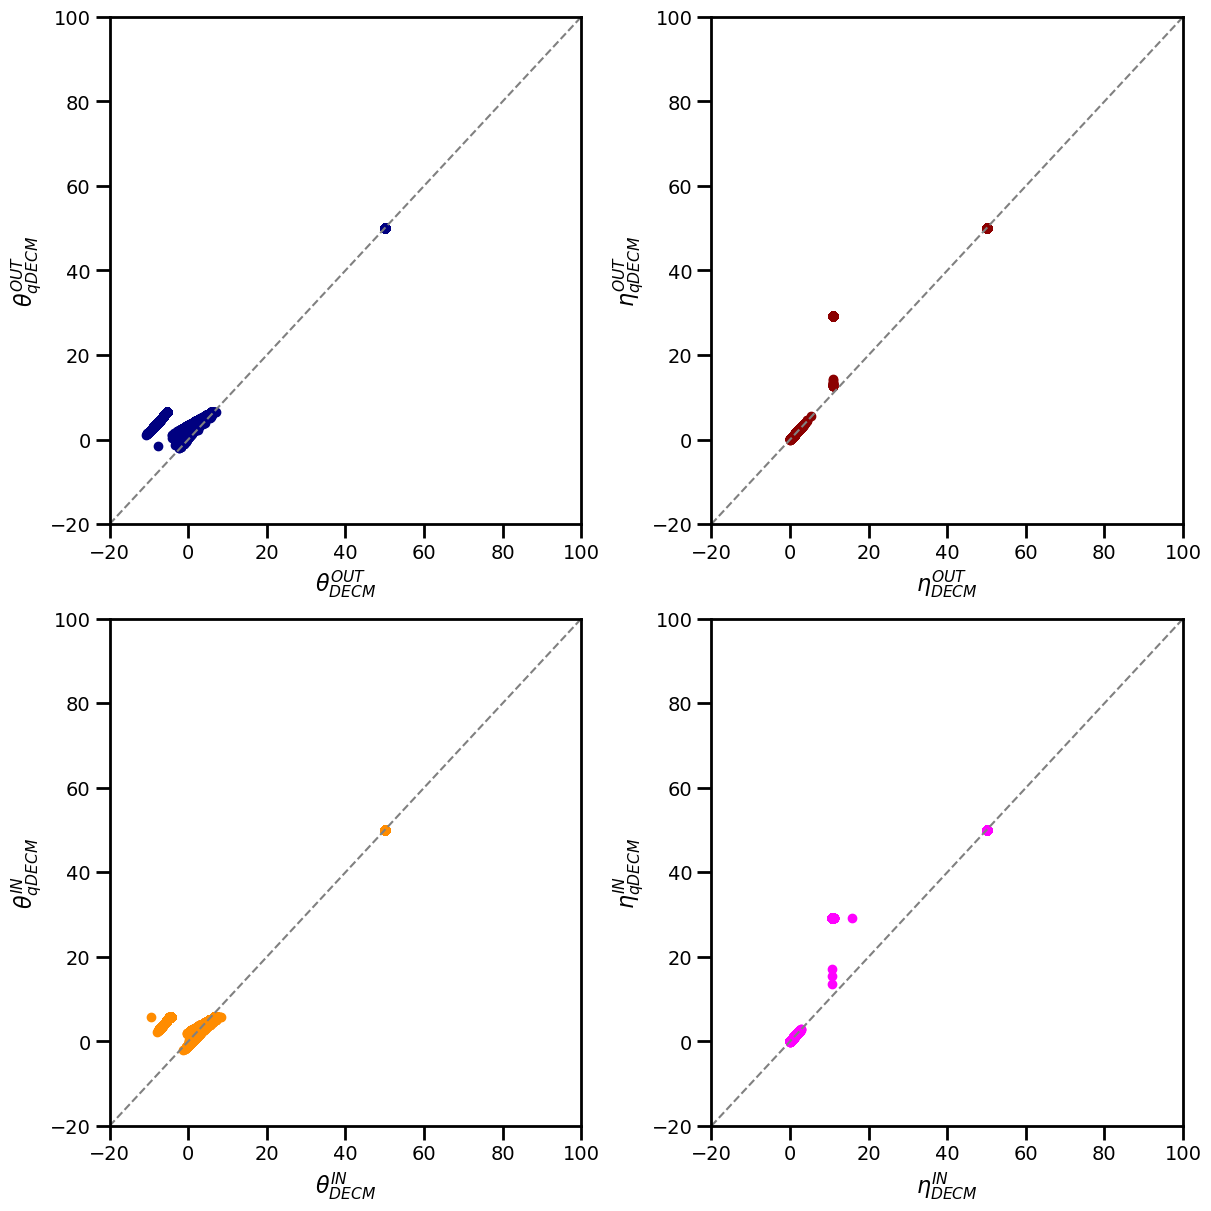

In [38]:
fig, axs= plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
colors=['navy', 'darkorange', 'darkred', 'magenta']
labels_decm=[r'$\theta^{OUT}_{DECM}$', r'$\theta^{IN}_{DECM}$', r'$\eta^{OUT}_{DECM}$', r'$\eta^{IN}_{DECM}$']
labels_qdecm=[r'$\theta^{OUT}_{qDECM}$', r'$\theta^{IN}_{qDECM}$', r'$\eta^{OUT}_{qDECM}$', r'$\eta^{IN}_{qDECM}$']
for i in range(2):
    for j in range(2):
        _decm_theta=decm_theta[i*l_theta//4+j*l_theta//2:(i+1)*l_theta//4+j*l_theta//2]
        _qdecm_theta=qdecm_theta[i*l_theta//4+j*l_theta//2:(i+1)*l_theta//4+j*l_theta//2]
        axs[i, j].scatter(_decm_theta, _qdecm_theta, color=colors[i + 2*j])
        axs[i, j].plot([-20,100], [-20,100], '--', color='gray')
        axs[i, j].set_xlim([-20, 100])
        axs[i, j].set_ylim([-20, 100])
        axs[i, j].set_xlabel(labels_decm[i + 2*j], fontsize=16)
        axs[i, j].set_ylabel(labels_qdecm[i + 2*j], fontsize=16)
plt.show()

### Probabilities and expected weights comparison

In [39]:
# colors and labels
colors=['orchid','darkcyan']
labels_decm=[r'$p_{DECM}$', r'$\langle w\rangle_{DECM}$']
labels_qdecm=[r'$p_{qDECM}$', r'$\langle w\rangle_{qDECM}$']

In [40]:
# probability matrices
p_decm=crisi_dico2_sols['decm'].pij_matrix(crisi_dico2_sols['decm'].sol.theta).flatten()
p_qdecm=crisi_dico2_sols['qdecm'].pij_matrix(crisi_dico2_sols['qdecm'].sol.theta[:l_theta//2]).flatten()

In [41]:
# weight matrices
w_decm=crisi_dico2_sols['decm'].wij_matrix(crisi_dico2_sols['decm'].sol.theta).flatten()
w_qdecm=crisi_dico2_sols['qdecm'].wij_matrix_conditioned(crisi_dico2_sols['qdecm'].sol.theta[:l_theta//2], crisi_dico2_sols['qdecm'].sol.theta[l_theta//2:]).flatten()


In [43]:
len(p_decm), len(p_qdecm), len(w_decm), len(w_qdecm)
print(f"Length of p_decm: {len(p_decm):.2e}")

Length of p_decm: 2.30e+08


In [43]:
f'{(l_theta//4)**2:.2e}'

'2.30e+08'

In [56]:
sample_size=10**6

In [59]:
selected_points=np.random.choice(np.arange(len(p_decm)), size=sample_size, replace=False)

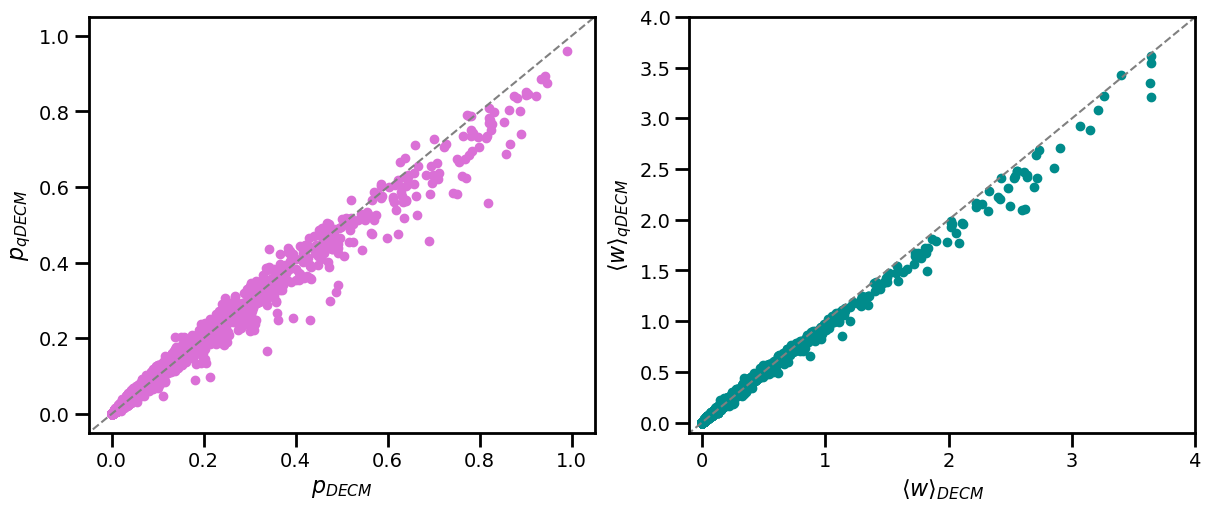

In [66]:
fig, axs= plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axs[0].scatter(p_decm[selected_points], p_qdecm[selected_points], color=colors[0])
axs[0].plot([-1,2], [-1,2], '--', color='gray')
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])

axs[1].scatter(w_decm[selected_points], w_qdecm[selected_points], color=colors[1])
axs[1].plot([-1,10], [-1,10], '--', color='gray')
axs[1].set_xlim([-0.1, 4])
axs[1].set_ylim([-0.1, 4])

    
for i in range(2):
    axs[i].set_xlabel(labels_decm[i], fontsize=16)
    axs[i].set_ylabel(labels_qdecm[i], fontsize=16)
plt.show()

## Maximum "error"

In [ ]:
w_mask=w_decm>0
p_mask=p_decm>0

In [84]:
torch.all(p_mask==w_mask)

tensor(True)

In [88]:
w_mask.sum()

tensor(62285440)

In [92]:
torch.all(p_qdecm[p_decm==0]==0)

tensor(True)

In [93]:
torch.all(w_qdecm[w_decm==0]==0)

tensor(True)

So, all the zero entries of p(DECM) are also zero according to qDECM. Good...

### Maximum absolute and relative error on $p$

In [120]:
abs_error_p=torch.abs(p_decm[w_mask]-p_qdecm[w_mask])
torch.max(abs_error_p)

tensor(0.4593, dtype=torch.float64)

In [121]:
where_max_abs_err_p=torch.where(abs_error_p==torch.max(abs_error_p))[0][0]

In [122]:
p_decm[w_mask][where_max_abs_err_p], p_qdecm[w_mask][where_max_abs_err_p]

(tensor(0.7785, dtype=torch.float64), tensor(0.3192, dtype=torch.float64))

In [123]:
torch.max(abs_error_p)/p_decm[w_mask][where_max_abs_err_p]

tensor(0.5900, dtype=torch.float64)

In [124]:
rel_error_p=torch.abs(p_decm[w_mask]-p_qdecm[w_mask])/p_decm[w_mask]
torch.max(rel_error_p)

tensor(4.9443, dtype=torch.float64)

In [125]:
where_max_rel_err_p=torch.where(rel_error_p==torch.max(rel_error_p))[0][0]

In [126]:
p_decm[w_mask][where_max_rel_err_p], p_qdecm[w_mask][where_max_rel_err_p]

(tensor(0.0024, dtype=torch.float64), tensor(0.0142, dtype=torch.float64))

In [127]:
abs_error_p[where_max_rel_err_p]

tensor(0.0118, dtype=torch.float64)

### Maximum absolute and relative error on $w$

In [128]:
abs_error_w=torch.abs(w_decm[w_mask]-w_qdecm[w_mask])
torch.max(abs_error_w)

tensor(61.1904, dtype=torch.float64)

In [129]:
where_max_abs_err_w=torch.where(abs_error_w==torch.max(abs_error_w))[0][0]

In [130]:
w_decm[w_mask][where_max_abs_err_w], w_qdecm[w_mask][where_max_abs_err_w]

(tensor(253.9513, dtype=torch.float64), tensor(315.1417, dtype=torch.float64))

In [131]:
torch.max(abs_error_w)/w_decm[w_mask][where_max_abs_err_w]

tensor(0.2410, dtype=torch.float64)

In [132]:
rel_error_w=torch.abs(w_decm[w_mask]-w_qdecm[w_mask])/w_decm[w_mask]
torch.max(rel_error_w)

tensor(4.9422, dtype=torch.float64)

In [133]:
where_max_rel_err_w=torch.where(rel_error_w==torch.max(rel_error_w))[0][0]

In [134]:
w_decm[w_mask][where_max_rel_err_w], w_qdecm[w_mask][where_max_rel_err_w]

(tensor(0.0024, dtype=torch.float64), tensor(0.0143, dtype=torch.float64))

In [135]:
abs_error_w[where_max_rel_err_w]

tensor(0.0119, dtype=torch.float64)

In [136]:
where_max_rel_err_w, where_max_rel_err_p

(tensor(45332149), tensor(45332149))

This is quite suspect...

# Summarising
1. so far, all algorithms follows a local Newton method, i.e. a Newton in which, instead of calculating the inverse of the Hessian, all entries are considered as independent (they are not). It works on every models for all datasets, but for DECM; In the cas eof DECM, it properly works on all test datasets (i.e. N~10k).
2. the only empirical network on which the DECM converge is crisis dico2. It converged by accident: the evolution of the MRE jumps around savagely until it find the proper path and then converges immediately. The same procedure was applied with no success on other dataset. All other tricks (backtracking, 2x2, different update phases) implemented did not work;
3. on crisi dico2 differences are impressive: the relative error on both the expected weights and the expected topology (i.e. $p$) is up to 5 (I mean, 500%), which is quite high. **A proper comparison should show how the p-value calculated with DECM and qDECM differ for our case, i.e. for the validation of the fluxes and the dimension of the blocks in the bowtie**; 
4. as DECM seems to goverge _extremely slowly_ to the proper solution, I can decide that I can wait for a couple of datasets considered as benchmarks, i.e. IV and DX (as they have the most marked bowtie structure) for the dataset used as benchmark, i.e. ita_elections. 
5. the likelihood, as calculated so far, needs to be checked. Consider also that on the networks that we decide to use as benchmarks, a model selection should be run **and** a fine justification for using qDECM instead of DECM should be found, even if BIC could never win (unless we used the _ad hoc_ defined generalized likelihood).
6. Hooray! o_o